In [8]:
import pandas as pd
import torch
import os
from sklearn.utils import resample
import torch.nn as nn
import esm
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [9]:
df = pd.read_csv("datasets/mutation_30mer_dataset153.csv")
patho_df = df[df["Label"] == 1]
benign_df = df[df["Label"] == 0]

min_count = min(len(patho_df), len(benign_df))

pathogenic_balanced = resample(patho_df, replace=False, n_samples=min_count, random_state=13)
benign_balanced = resample(benign_df, replace=False, n_samples=min_count, random_state=13)

balanced_df = pd.concat([pathogenic_balanced, benign_balanced]).sample(frac=1, random_state=13) 
balanced_df.to_csv("esm2_balanced_ds.csv", index=False)

sequences = balanced_df["Mut_30mer"].tolist()
labels = balanced_df["Label"].tolist()

In [10]:
model, alphabet = esm.pretrained.esm2_t30_150M_UR50D()
model = model.to(device)
batch_converter = alphabet.get_batch_converter()
model.eval()

ESM2(
  (embed_tokens): Embedding(33, 640, padding_idx=1)
  (layers): ModuleList(
    (0-29): 30 x TransformerLayer(
      (self_attn): MultiheadAttention(
        (k_proj): Linear(in_features=640, out_features=640, bias=True)
        (v_proj): Linear(in_features=640, out_features=640, bias=True)
        (q_proj): Linear(in_features=640, out_features=640, bias=True)
        (out_proj): Linear(in_features=640, out_features=640, bias=True)
        (rot_emb): RotaryEmbedding()
      )
      (self_attn_layer_norm): LayerNorm((640,), eps=1e-05, elementwise_affine=True)
      (fc1): Linear(in_features=640, out_features=2560, bias=True)
      (fc2): Linear(in_features=2560, out_features=640, bias=True)
      (final_layer_norm): LayerNorm((640,), eps=1e-05, elementwise_affine=True)
    )
  )
  (contact_head): ContactPredictionHead(
    (regression): Linear(in_features=600, out_features=1, bias=True)
    (activation): Sigmoid()
  )
  (emb_layer_norm_after): LayerNorm((640,), eps=1e-05, elementw

In [11]:
if not os.path.exists("esm2_embeddings.csv"):
    all_embeddings = []

    batch_size = 32
    for i in range(0, len(sequences), batch_size):
        batch_seqs = sequences[i:i + batch_size]
        batch_labels = [f"seq{i+j}" for j in range(len(batch_seqs))]
        batch_tuples = list(zip(batch_labels, batch_seqs))

        _, _, batch_tokens = batch_converter(batch_tuples)
        batch_tokens = batch_tokens.to(device)
        with torch.no_grad():
            out = model(batch_tokens, repr_layers=[12])

        reps = out["representations"][12]

        for j, seq in enumerate(batch_seqs):
            rep = reps[j, 1:len(seq)+1].mean(0)
            all_embeddings.append(rep.to('cpu').numpy())

    embedding_df = pd.DataFrame(all_embeddings)
    embedding_df["Label"] = labels
    embedding_df.to_csv("esm2_embeddings.csv", index=False)

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = embedding_df

X = df.drop(columns=["Label"]).values
y = df["Label"].values

clf = LogisticRegression(max_iter=700)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, stratify=y)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_val)

c:\Users\brian\Documents\! Grad School\Classes\CSE 566\Mutation-Prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Evaluation Metrics:
 {'Accuracy': 0.6539440203562341, 'Precision': 0.6631016042780749, 'Recall': 0.6294416243654822, 'F1 Score': 0.6458333333333334}


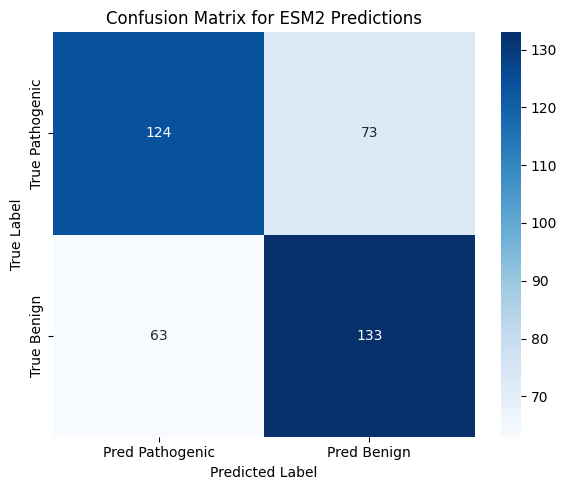

In [ ]:
metrics = {
    'Accuracy': accuracy_score(y_val, y_pred),
    'Precision': precision_score(y_val, y_pred),
    'Recall': recall_score(y_val, y_pred),
    'F1 Score': f1_score(y_val, y_pred),
}
print("Evaluation Metrics:\n", metrics)

conf_matrix = confusion_matrix(y_val, y_pred, labels=[1, 0])
report = classification_report(y_val, y_pred, labels=[1, 0], target_names=["pathogenic", "benign"], output_dict=True)

conf_df = pd.DataFrame(conf_matrix, index=["True Pathogenic", "True Benign"],
                       columns=["Pred Pathogenic", "Pred Benign"])
plt.figure(figsize=(6, 5))
sns.heatmap(conf_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix for ESM2 Predictions")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

C:\Users\brian\AppData\Local\Temp\ipykernel_34248\3736299834.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=metrics_df.index, x=metrics_df["Value"], palette="coolwarm")


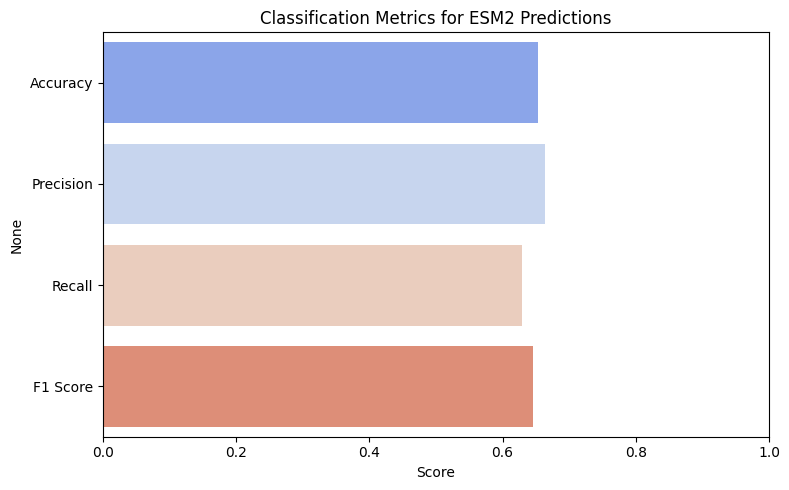

In [16]:
metrics_df = pd.DataFrame.from_dict(metrics, orient="index", columns=["Value"])
plt.figure(figsize=(8, 5))
sns.barplot(y=metrics_df.index, x=metrics_df["Value"], palette="coolwarm")
plt.title("Classification Metrics for ESM2 Predictions")
plt.xlabel("Score")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

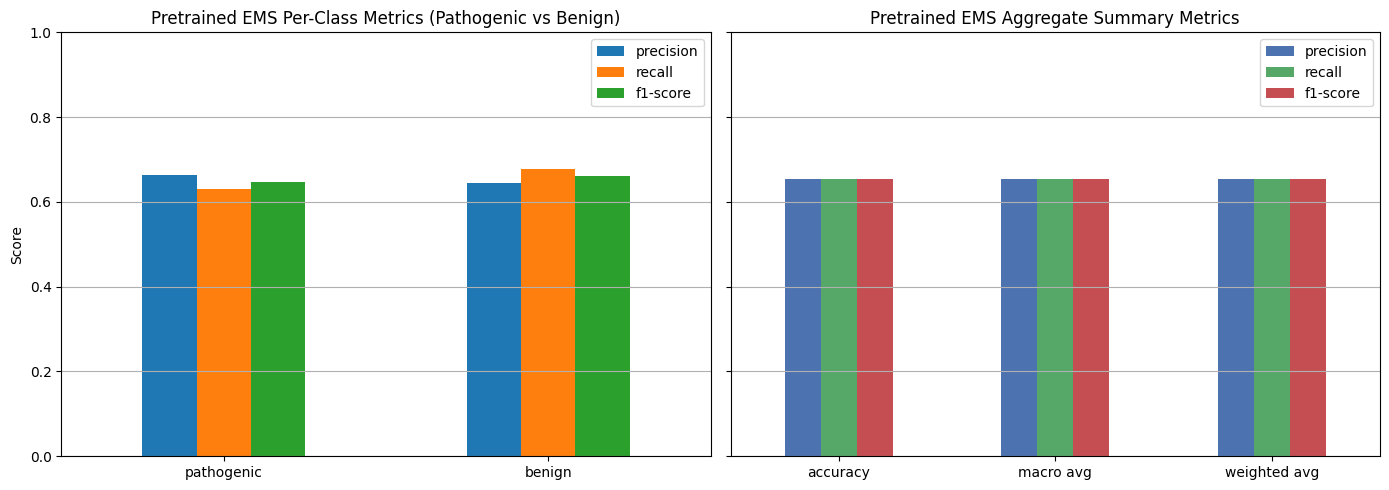

In [17]:
report_df = pd.DataFrame(report).transpose()

class_metrics = report_df.loc[['pathogenic', 'benign']]
summary_metrics = report_df.loc[['accuracy', 'macro avg', 'weighted avg']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

class_metrics[['precision', 'recall', 'f1-score']].plot(kind='bar', ax=axes[0])
axes[0].set_title("Pretrained EMS Per-Class Metrics (Pathogenic vs Benign)")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1)
axes[0].grid(True, axis='y')
axes[0].set_xticklabels(class_metrics.index, rotation=0)

summary_metrics[['precision', 'recall', 'f1-score']].plot(kind='bar', ax=axes[1], color=['#4c72b0', '#55a868', '#c44e52'])
axes[1].set_title("Pretrained EMS Aggregate Summary Metrics")
axes[1].set_ylim(0, 1)
axes[1].grid(True, axis='y')
axes[1].set_xticklabels(summary_metrics.index, rotation=0)

plt.tight_layout()
plt.show()

In [18]:
print("\nFull Classification Report:")
print(pd.DataFrame(report).transpose())


Full Classification Report:
              precision    recall  f1-score     support
pathogenic     0.663102  0.629442  0.645833  197.000000
benign         0.645631  0.678571  0.661692  196.000000
accuracy       0.653944  0.653944  0.653944    0.653944
macro avg      0.654366  0.654007  0.653762  393.000000
weighted avg   0.654389  0.653944  0.653742  393.000000


Full Classification Report:
              precision    recall  f1-score     support
pathogenic     0.645000  0.658163  0.651515  196.000000
benign         0.652850  0.639594  0.646154  197.000000
accuracy       0.648855  0.648855  0.648855    0.648855
macro avg      0.648925  0.648879  0.648834  393.000000
weighted avg   0.648935  0.648855  0.648828  393.000000